In [ ]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Models
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [ ]:
df = pd.read_csv("work_from_home_burnout_dataset.csv")

In [ ]:
df.head()

,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk
0,1,Weekday,9.59,11.86,4,2,0,7.55,91.2,19.17,Low
1,1,Weekend,7.38,10.33,4,1,0,6.69,82.0,29.70,Low
2,1,Weekend,6.31,8.92,1,2,0,8.87,80.6,32.93,Low
3,1,Weekday,8.34,10.70,4,1,1,8.13,70.0,45.47,Low
4,1,Weekend,6.97,9.83,1,2,0,5.85,67.1,51.61,Low


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               1800 non-null   int64  
 1   day_type              1800 non-null   object 
 2   work_hours            1800 non-null   float64
 3   screen_time_hours     1800 non-null   float64
 4   meetings_count        1800 non-null   int64  
 5   breaks_taken          1800 non-null   int64  
 6   after_hours_work      1800 non-null   int64  
 7   sleep_hours           1800 non-null   float64
 8   task_completion_rate  1800 non-null   float64
 9   burnout_score         1800 non-null   float64
 10  burnout_risk          1800 non-null   object 
dtypes: float64(5), int64(4), object(2)
memory usage: 154.8+ KB


In [ ]:
df["burnout_risk"].value_counts()

,count
burnout_risk,
Low,1527
Medium,253
High,20


In [ ]:
df.describe()

,user_id,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score
count,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000
mean,90.500000,6.515117,9.271406,1.941111,3.028889,0.358889,6.996467,72.308556,44.009978
std,51.975162,2.290521,2.409253,1.696178,1.417844,0.479808,1.061740,14.978647,23.881782
min,1.000000,3.000000,4.510000,0.000000,1.000000,0.000000,4.500000,40.000000,2.500000
25%,45.750000,4.430000,7.240000,1.000000,2.000000,0.000000,6.280000,62.300000,25.370000
50%,90.500000,6.445000,9.210000,2.000000,3.000000,0.000000,6.990000,74.500000,39.270000
75%,135.250000,8.510000,11.310000,3.000000,4.000000,1.000000,7.750000,83.700000,58.197500
max,180.000000,12.170000,15.700000,10.000000,5.000000,1.000000,10.800000,107.200000,143.920000


In [ ]:
df.isnull().sum()

,0
user_id,0
day_type,0
work_hours,0
screen_time_hours,0
meetings_count,0
breaks_taken,0
after_hours_work,0
sleep_hours,0
task_completion_rate,0
burnout_score,0


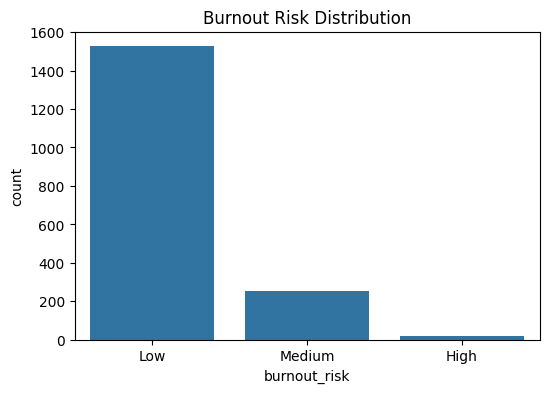

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="burnout_risk", data=df)
plt.title("Burnout Risk Distribution")
plt.show()

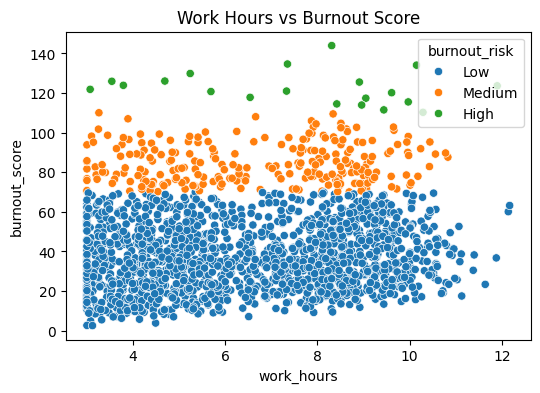

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="work_hours", y="burnout_score", hue="burnout_risk", data=df)
plt.title("Work Hours vs Burnout Score")
plt.show()

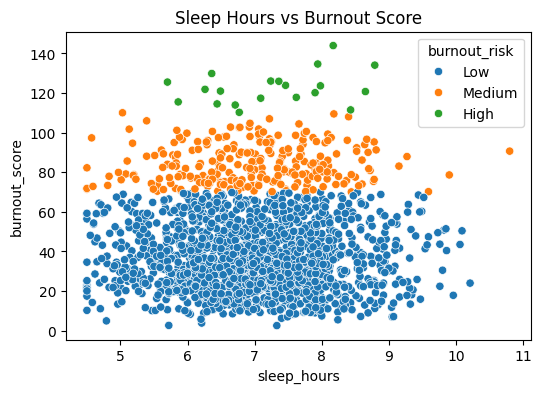

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="sleep_hours", y="burnout_score", hue="burnout_risk", data=df)
plt.title("Sleep Hours vs Burnout Score")
plt.show()

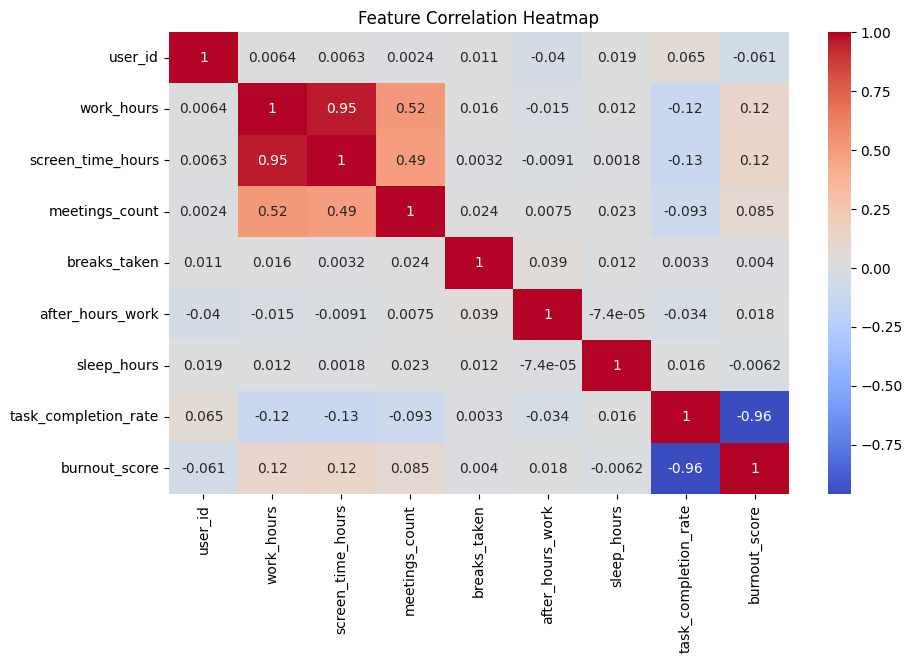

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
le = LabelEncoder()
df["day_type"] = le.fit_transform(df["day_type"])

In [ ]:
features = [
    "day_type",
    "work_hours",
    "screen_time_hours",
    "meetings_count",
    "breaks_taken",
    "after_hours_work",
    "sleep_hours",
    "task_completion_rate"
]

X = df[features]
y = df["burnout_score"]

In [ ]:
X = df[features]

# Target for classification (burnout risk)
y_class = df["burnout_risk"].map({"Low": 0, "Medium": 0, "High": 2})

# y_class = df["burnout_risk"].map({"Low": 0, "Medium":1, "High": 2})

In [ ]:
from sklearn.model_selection import train_test_split

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_c, y_train_c)


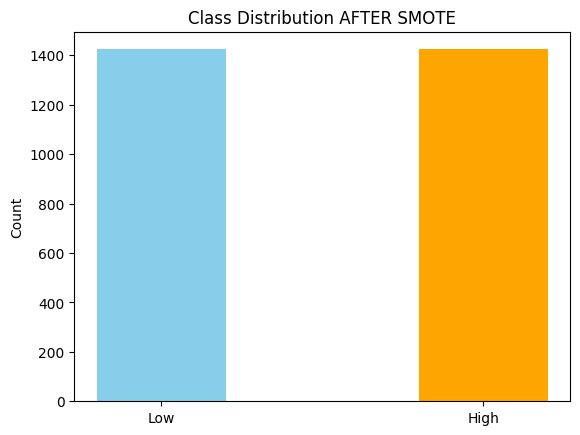

In [ ]:
plt.bar(y_train_smote.value_counts().index, y_train_smote.value_counts().values,
        color=['skyblue','orange'])
plt.xticks([0,2], ['Low', 'High'])
plt.ylabel("Count")
plt.title("Class Distribution AFTER SMOTE")
plt.show()

In [ ]:
scaler_c = StandardScaler()

X_train_smote_scaled = scaler_c.fit_transform(X_train_smote)
X_test_c_scaled = scaler_c.transform(X_test_c)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight=None
)

rf_clf.fit(X_train_smote_scaled, y_train_smote)

rf_preds = rf_clf.predict(X_test_c_scaled)

In [ ]:
print("Random Forest Accuracy:", accuracy_score(y_test_c, rf_preds))
print("\nRandom Forest Classification Report:\n",
      classification_report(y_test_c, rf_preds,
                            target_names=["Low", "High"]))

Random Forest Accuracy: 0.975

Random Forest Classification Report:
               precision    recall  f1-score   support

         Low       0.99      0.99      0.99       356
        High       0.00      0.00      0.00         4

    accuracy                           0.97       360
   macro avg       0.49      0.49      0.49       360
weighted avg       0.98      0.97      0.98       360



In [ ]:
log_reg = LogisticRegression(
    max_iter=1000,
    multi_class="multinomial"
)

log_reg.fit(X_train_smote_scaled, y_train_smote)

lr_preds = log_reg.predict(X_test_c_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


In [ ]:
print("Logistic Regression Accuracy:", accuracy_score(y_test_c, lr_preds))
print("\nLogistic Regression Classification Report:\n",
      classification_report(y_test_c, lr_preds,
                            target_names=["Low", "High"]))

Logistic Regression Accuracy: 0.9416666666666667

Logistic Regression Classification Report:
               precision    recall  f1-score   support

         Low       1.00      0.94      0.97       356
        High       0.16      1.00      0.28         4

    accuracy                           0.94       360
   macro avg       0.58      0.97      0.62       360
weighted avg       0.99      0.94      0.96       360



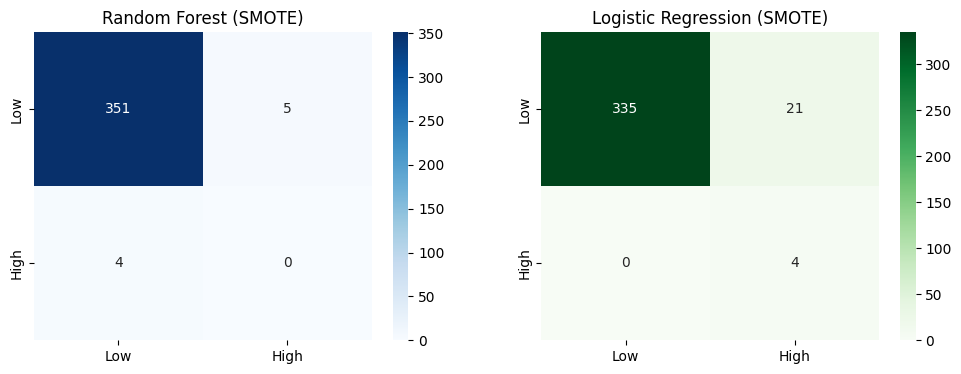

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.heatmap(confusion_matrix(y_test_c, rf_preds),
            annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low","High"],
            yticklabels=["Low","High"])
plt.title("Random Forest (SMOTE)")

plt.subplot(1,2,2)
sns.heatmap(confusion_matrix(y_test_c, lr_preds),
            annot=True, fmt="d", cmap="Greens",
            xticklabels=["Low","High"],
            yticklabels=["Low","High"])
plt.title("Logistic Regression (SMOTE)")

plt.show()

In [ ]:
sample = pd.DataFrame({
    "day_type": [1],
    "work_hours": [9.5],
    "screen_time_hours": [12.2],
    "meetings_count": [5],
    "breaks_taken": [1],
    "after_hours_work": [1],
    "sleep_hours": [5.6],
    "task_completion_rate": [60]
})

In [ ]:
sample_scaled = scaler_c.transform(sample)

In [ ]:
sample_pred_rf = rf_clf.predict(sample_scaled)[0]

In [ ]:
sample_pred_lr = log_reg.predict(sample_scaled)[0]

In [ ]:
# risk_labels = {0: "Low", 1: "Medium", 2: "High"}
risk_labels = {0: "Low",  1: "High"}

print("Random Forest Predicted Burnout Risk:", risk_labels[sample_pred_rf])
print("Logistic Regression Predicted Burnout Risk:", risk_labels[sample_pred_lr])

Random Forest Predicted Burnout Risk: Low
Logistic Regression Predicted Burnout Risk: Low


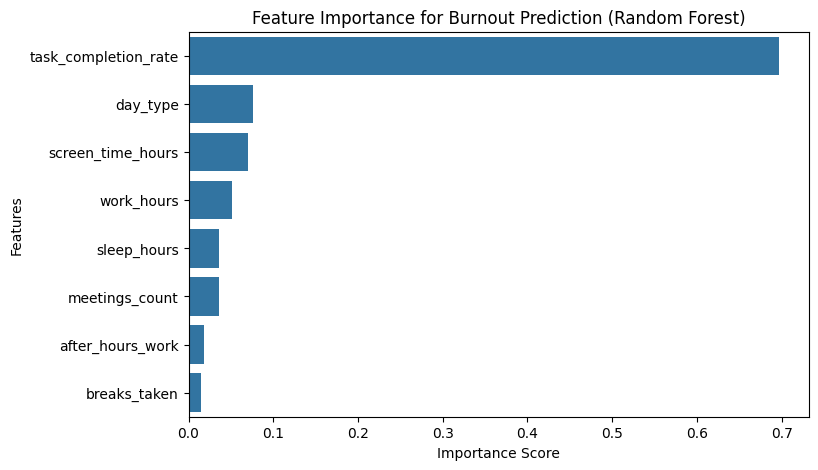

In [ ]:
feature_importance = pd.Series(rf_clf.feature_importances_, index=features)

feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=feature_importance.values, y=feature_importance.index)

plt.title("Feature Importance for Burnout Prediction (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

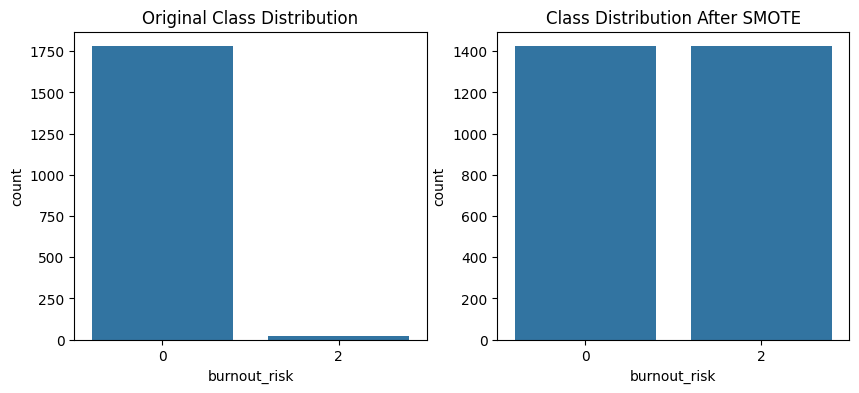

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.countplot(x=y_class)
plt.title("Original Class Distribution")

plt.subplot(1,2,2)
sns.countplot(x=y_train_smote)
plt.title("Class Distribution After SMOTE")

plt.show()

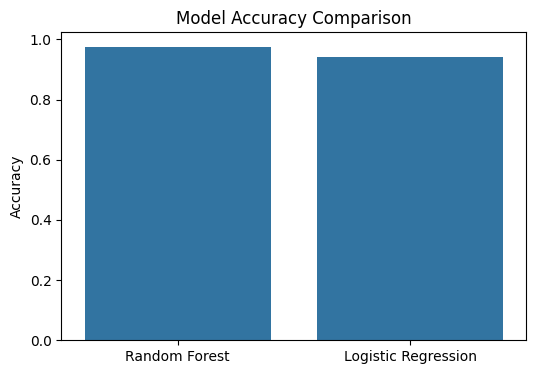

In [ ]:
model_names = ["Random Forest", "Logistic Regression"]

model_scores = [
    accuracy_score(y_test_c, rf_preds),
    accuracy_score(y_test_c, lr_preds)
]

plt.figure(figsize=(6,4))
sns.barplot(x=model_names, y=model_scores)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()